## SNEEK PEAK

In [1]:
from micrograd.engine import Value

a = Value(-4.0) 
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1 
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0
'''
Therefore, we are building an expression graph {Hidden Layer} -> with these two values 'a' and 'b' as 
an input {Input Layer} -> producing an output of 'g' {Output Layer}
So micrograd in the background will create that entire mathematical expression (from c to f) {Therefore acts as that Hidden Layer}
'''
print(f"{g.data:.4f}, the outcome of this forward pass")
'''
Apart from just doing a Forward Pass, i.e. finding g.
We are also going to perform Backpropagation where we find the derivative of g by going backwards 
from output -> hidden -> input by recursively applying chain of rule (from calculus).
So what that allows us to do, is to find the derivative of g w.r.t to all the internal nodes i.e. f, d, c and the input nodes i.e. a & b.
Then we can query the derivative of g w.r.t a
'''
g.backward() 
print(f"{a.grad:.4f}, i.e. the numerical value of dg/da")
print(f"{b.grad:.4f}, i.e. the numerical value of dg/db")

34.5000, the outcome of this forward pass
140.0000, i.e. the numerical value of dg/da
651.0000, i.e. the numerical value of dg/db


## DERIVATIVE SIMPLER FUNCTION

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

In [5]:
xs = np.arange(-5,5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [6]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

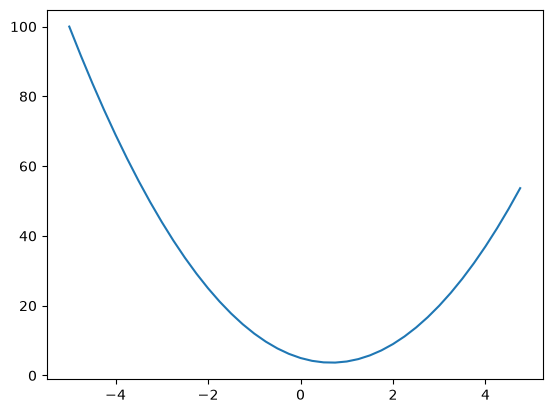

In [7]:
plt.plot(xs, ys)

In [8]:
h = 0.001
x = 3.0
f(x+h)

20.014003000000002

In [9]:
# Next we have to normalise it by adding the value rise of the run i.e. h, to get the value of the slope AKA DERIVATIVE
(f(x+h) - f(x))/h 

14.00300000000243

In [10]:
# Now at some point the slop must be 0, therefore nudging a small value either way from that point, it still remains 0
# In this case, for the function it is at around x = 2/3
h = 0.00000001
x = 2/3
(f(x+h) - f(x))/h

0.0

## Derivative Function with Multiple Inputs

In [11]:
a = 2.0
b = -3.0
c = 10.0

d = a*b + c

In [12]:
h = 0.0001
a += h
d2 = a * b + c
print("d :", d)
print("d2 :", d2)

d : 4.0
d2 : 3.999699999999999


In [13]:
print("slope :", ((d2-d)/h)) # Kinda Partial Derivative

slope : -3.000000000010772


In [14]:
a = 2.0
b = -3.0
c = 10.0
h = 0.0001
d1 = a*b + c

In [15]:
b += h

d2 = a*b + c

print('d1', d1)
print('d2', d2)

print('Slope: ', (d2 - d1)/h)

d1 4.0
d2 4.0002
Slope:  2.0000000000042206


In [16]:
a = 2.0
b = -3.0
c = 10.0
h = 0.0001
d1 = a*b + c

In [17]:
c += h

d2 = a*b + c

print('d1', d1)
print('d2', d2)

print('Slope: ', (d2 - d1)/h)

d1 4.0
d2 4.0001
Slope:  0.9999999999976694


In [18]:
%reset -f

## Value object creation

In [19]:
class Value: # What we saw above 
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"       
    #__repr__ merely gives that node a readable display name:

 

In [20]:
a = Value(2.0) 
b = Value(-3.0) 

In [21]:
%reset -f

## Visualization of the expression (DATA STRUCTURE)

In [22]:
## Final code after adding method (ADD)
class Value:
    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other))
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other))
        return out

In [23]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a * b + c
d

Value(data=4.0)

In [24]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [25]:
## We know what childrens were use to create, but we arent aware abouth the operations used with them 

In [26]:
%reset -f

In [27]:
## Final code after adding method (ADD)
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 
        self._op = _op 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [28]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a * b + c
d

Value(data=4.0)

In [29]:
d._op

'+'

In [30]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

## Graph Visualisation

In [31]:
%reset -f

In [32]:
# Same graph, but we are just adding labels

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 
        self._op = _op 
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [33]:
import networkx as nx
import matplotlib.pyplot as plt


def trace(root):
    """Collect all nodes and edges in the computation graph."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    nodes, edges = trace(root)

    G = nx.DiGraph()

    # Add nodes
    for node in nodes:
        G.add_node(node)

    # Add edges
    for child, parent in edges:
        G.add_edge(child, parent)

    # Calculate depth so graph flows left → right
    depth = {}

    def assign_depth(node, d=0):
        depth[node] = max(depth.get(node, 0), d)

        for prev in node._prev:
            assign_depth(prev, d + 1)

    assign_depth(root)

    # Group nodes according to depth
    levels = {}

    for node, d in depth.items():
        levels.setdefault(d, []).append(node)

    pos = {}

    max_depth = max(levels)

    for d, level_nodes in levels.items():
        for i, node in enumerate(level_nodes):

            x = max_depth - d

            y = i - (len(level_nodes) - 1) / 2

            pos[node] = (x, y)

    # Labels
    labels = {}

    for node in nodes:
        label = node.label if node.label else "?"
        labels[node] = f"{label}\nvalue = {node.data}"

    plt.figure(figsize=(8, 4))

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=3500,
        font_size=10,
        arrows=True,
        arrowsize=20
    )

    # Show operations on edges
    edge_labels = {}

    for child, parent in edges:
        if parent._op:
            edge_labels[(child, parent)] = parent._op

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=11
    )

    plt.title("Computation Graph")
    plt.axis("off")
    plt.show()

In [34]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d= e + c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

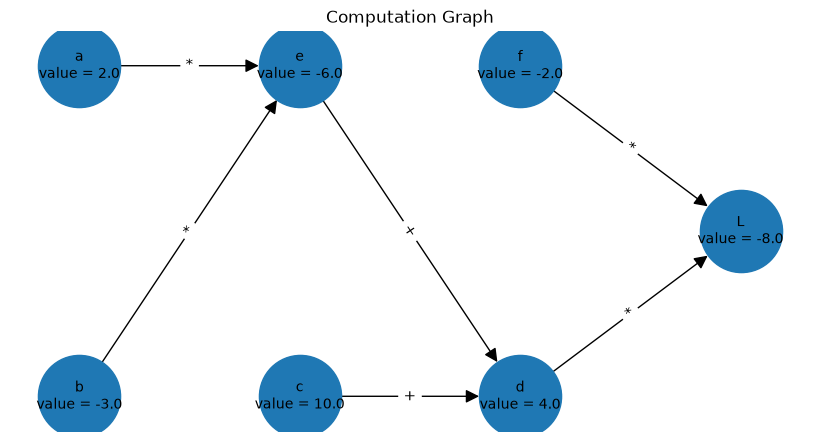

In [35]:
draw_dot(L)

## Backprop - 1

In [36]:
%reset -f

In [38]:
# Therefore during initialization, the gradient values will be set to 0 as we believe that those initial values do not affect the value of the output.

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 
        self._op = _op 
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [39]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d= e + c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

In [40]:
import networkx as nx
import matplotlib.pyplot as plt


def trace(root):
    """Collect all nodes and edges in the computation graph."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    nodes, edges = trace(root)

    G = nx.DiGraph()

    # Add nodes
    for node in nodes:
        G.add_node(node)

    # Add edges
    for child, parent in edges:
        G.add_edge(child, parent)

    # Calculate depth so graph flows left → right
    depth = {}

    def assign_depth(node, d=0):
        depth[node] = max(depth.get(node, 0), d)

        for prev in node._prev:
            assign_depth(prev, d + 1)

    assign_depth(root)

    # Group nodes according to depth
    levels = {}

    for node, d in depth.items():
        levels.setdefault(d, []).append(node)

    pos = {}

    max_depth = max(levels)

    for d, level_nodes in levels.items():
        for i, node in enumerate(level_nodes):

            x = max_depth - d

            y = i - (len(level_nodes) - 1) / 2

            pos[node] = (x, y)

    # Labels
    labels = {}

    for node in nodes:
        label = node.label if node.label else "?"
        labels[node] = f"{label}\nvalue = {node.data}"

    plt.figure(figsize=(8, 4))

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=3500,
        font_size=10,
        arrows=True,
        arrowsize=20
    )

    # Show operations on edges
    edge_labels = {}

    for child, parent in edges:
        if parent._op:
            edge_labels[(child, parent)] = parent._op

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=11
    )

    plt.title("Computation Graph")
    plt.axis("off")
    plt.show()

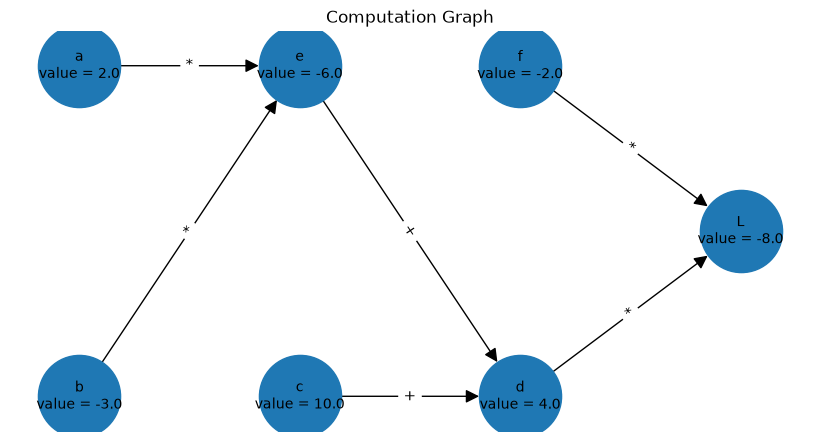

In [41]:
draw_dot(L)

## Now, let's start to fill those grad values

In [42]:
#This is just a staging function to show how the calculation of each of the derivative is taking place
def DILCHASP():

  h = 0.001

  #Here we are basically making them as local variables, to not affect the global variables on top
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data #L is basically a node, so we need its data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data + h

  print((L2-L1)/h)

DILCHASP()

1.000000000000334


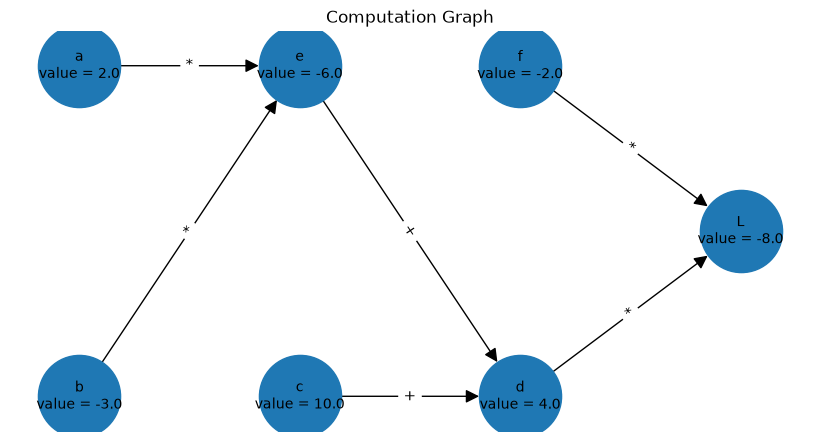

In [43]:
# This was theoritically obvious as well. The derivitive of L wrt L will be one.
L.grad = 1.0 # lets add that value manually
draw_dot(L)

In [44]:
# L wrt to f and d